<b>Time series classification with custom CSV-data</b>

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Increase display width
pd.set_option("display.width", 1000)

In [2]:
# our data is in two files, let's combine them for easier manipulation 
# for a complete dataset
df1 = pd.read_csv("DailyDelhiClimateTest.csv")
df2 = pd.read_csv("DailyDelhiClimateTrain.csv")
df = pd.concat([df1, df2])

In [3]:
# one time variable, and four numeric variables
df

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333
...,...,...,...,...,...
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000


In [4]:
# we're going to choose meantemp and wind_speed for this example
# also drop the date and use sequence number instead
df = df.drop(["date", "humidity", "meanpressure"], axis=1)

In [5]:
# scale the temperature and wind_values
scaler = MinMaxScaler()
df[["meantemp", "wind_speed"]] = scaler.fit_transform(df[["meantemp", "wind_speed"]])

In [6]:
# now the data is pretty ok to work further with
df

,meantemp,wind_speed
0,0.303019,0.064981
1,0.382096,0.068556
2,0.339641,0.095137
3,0.388210,0.107650
4,0.378700,0.078162
...,...,...
1457,0.342890,0.084032
1458,0.282387,0.142113
1459,0.247453,0.148429
1460,0.276718,0.173496


<b>The time step process - we have to divide the data into signal segments (time steps)</b>

In [7]:
# let's try 50 as the step size
# this means our 1576 rows of data is going to be split 
# with 50. we also have to discard last 26 rows in order to have same
# size in each time step

# so in the end 1550 / 50 = 31 time step segments (each containing 50 points)
# but since we have two variables, we have to double the amounts
# so we are going to have 31 * 2 = 62 time step segments (each containing 50 points)
# so in this case 62 * 50 = 3100 unique measurement values (temperatures and wind speeds)
step_size = 50

# we're going to have 0 for meantemp, and 1 for wind_speed
# save these into the helper lists, used later
class_names = np.array(["meantemp", "wind_speed"])
num_classes = len(class_names)
classes = [0, 1]

######################################
# TIME STEP DATA PREPARATION -PHASE! #
######################################

# instead of date, we're going to use a sequence number
# index + 1 => the sequence will be from 1 - 1576
df['sequence'] = df.index + 1

# next step, use melting to make the data in order to 
# have only one variable for measurement value, and a helper variable
# to determine if the value is mean temperature or wind speed
df = pd.melt(df, id_vars=["sequence"], value_vars=["meantemp", "wind_speed"],
             var_name="class", value_name="measurement")

# replace the original variable names into target output variable
# values => 0 or 1, depending if the signal is temperature or wind
df['class'] = df['class'].replace({"meantemp": 0, "wind_speed": 1})


# we have to split the DataFrame into separate DataFrames
# based on their target variable (temperature or wind_speed)
df_class_1 = df[df['class'] == 0]
df_class_2 = df[df['class'] == 1]

# combine into a list for easier iteration
# WHEN WE DO THE TIMESTEP SPLIT
splitted_dfs = [df_class_1, df_class_2]


C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_12736\2369073660.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['class'] = df['class'].replace({"meantemp": 0, "wind_speed": 1})


In [8]:
######################
# TIME SPLIT PROCESS #
######################

# our final index is going to be 1550 (evens out the amount of values
# so that we get even splits)
max_size = 1550

# split size is 50, so each segment is going to have 50 data points
time_step_size = 50

# empty list for data points
# this will have the time step segments
# so this will basically have 62 lists inside it, each list containing 50 values
# 31 temperature lists and 31 wind speed lists
X_data = []

# for each 62 lists, we need to have 1 target output value
# in this case, 31 values of 0 (temperatures) and 31 values of 1 (wind_speed)
# i.e. target categories
y_data = []

# helper variable to keep track of slicing the original DataFrame
start_index = 0

# built X_data and y_data for all categories (2 at this point)
# see the classes -list in the previous phase
for category in classes:
    # we will start cutting the original signal data
    # starting from index 0
    index_cutoff = 0

    while index_cutoff / max_size < 1:
        timestep = []

        # take a slice of 50 points, starting from cutoff until cutoff + 50
        slice = splitted_dfs[category].iloc[index_cutoff:index_cutoff + time_step_size]
    
        # take a slice of selected category / signal type
        # and place it in x_total and y_total
        X_data.append(list(slice['measurement']))
        y_data.append(category)

        # after each slicing operation, increase the cutoff
        # by 50 (step size), otherwise we get an infinite
        index_cutoff += time_step_size


# wrap the data lists around NumPy arrays
X_data = np.array(X_data)
y_data = np.array(y_data)

In [9]:
# compare this data format now to the italy power data
# this was achieved by the above code cells
# the exact code implementation is a bit different depending on situation
X_data

array([[0.3030188 , 0.38209607, 0.33964095, ..., 0.46768559, 0.46233624,
        0.50019849],
       [0.53111354, 0.48398836, 0.40120087, ..., 0.59989083, 0.64574236,
        0.66812227],
       [0.71069869, 0.71069869, 0.72343523, ..., 0.36681223, 0.34934498,
        0.32478166],
       ...,
       [0.11132165, 0.19058898, 0.13175036, ..., 0.10404056, 0.16935102,
        0.17224064],
       [0.13796779, 0.21089167, 0.15939435, ..., 0.15781532, 0.16613656,
        0.16854571],
       [0.18162439, 0.15299051, 0.21610611, ..., 0.13421759, 0.11729941,
        0.05930474]], shape=(62, 50))

In [10]:
# and the correct predictions for each time step signal
# is stored in this variable, just like in the italy power example
y_data

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [11]:
# just checking that we still have original amount of data for temperatures
df_class_1['class'].value_counts()

class
0    1576
Name: count, dtype: int64

In [12]:
# just checking that we still have original amount of data for wind speed too
df_class_2['class'].value_counts()

class
1    1576
Name: count, dtype: int64

<b>Let's plot one of the signal pairs</b>

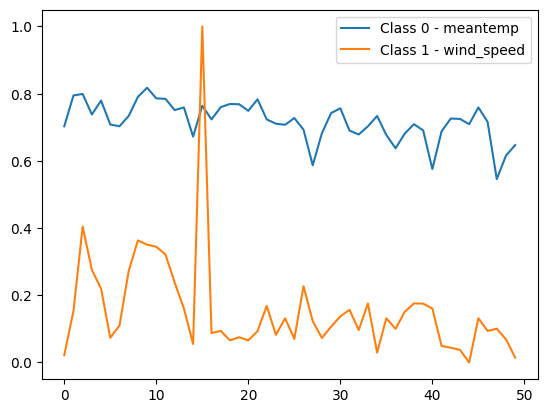

In [13]:
import matplotlib.pyplot as plt

test_signal_index = 7

c_x_train = X_data[y_data == 0]
plt.plot(c_x_train[test_signal_index], label="Class 0 - meantemp")

c_x_train = X_data[y_data == 1]
plt.plot(c_x_train[test_signal_index], label="Class 1 - wind_speed")
plt.legend()

<b>Let's randomize the data order a bit, it's usually better for training)</b>

In [14]:
# randomize the data, because now they are in order
# by the target variable, which is a problem for a neural network

# shuffle the data so that we don't 
# break the pairings of X_data and y_data (signal segments and their correct output class)
import random
zipped = list(zip(X_data, y_data))
random.shuffle(zipped)
X_data, y_data = zip(*zipped)

# transfrom back to NumPy format
X_data = np.array(X_data)
y_data = np.array(y_data)
X_data = np.expand_dims(X_data, axis=1)

<b>Train/test -split<b/>

In [15]:
 # let's make a helper variabel to split our dataset
train_size = 0.7
splitter = int(len(X_data) * train_size)

# split by the index
X_train = X_data[0:splitter]
X_test = X_data[splitter:]
y_train = y_data[0:splitter]
y_test = y_data[splitter:]

<b>Train the model</b>

In [16]:
# step 3 - specify the classifier
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
from sktime.dists_kernels import FlatDist, ScipyDist

eucl_dist = FlatDist(ScipyDist())
clf = KNeighborsTimeSeriesClassifier(n_neighbors=3, distance=eucl_dist)

# step 4 - fit/train the classifier
clf.fit(X_train, y_train)

# step 5 - predict labels on new data
y_pred = clf.predict(X_test)

<b>Error metrics etc.</b>

<Axes: >

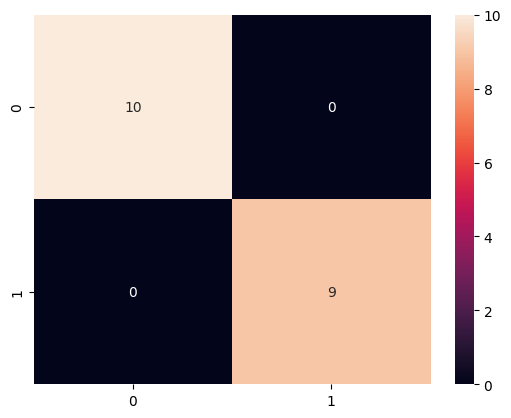

In [17]:
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import seaborn as sns

test_predictions = y_pred

# confusion matrix
sns.heatmap(confusion_matrix(y_test, test_predictions), annot=True, fmt='g')

In [18]:
 # print the classification report based on true values and predictions
print(classification_report(y_test, test_predictions))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, test_predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19


Model overall accuracy: 100.00%


<b>Let's loop through test data and our predictions</b>

In [19]:
# make a prediction from test data, change the index in order
# to try another index
for x in range(19):
    test_signal = X_test[x]
    test_signal = np.expand_dims(test_signal, axis=0)
    result = clf.predict(test_signal)
    probabilities = clf.predict_proba(test_signal)
    index = result[0]
    print(f"Prediction result: {result}")
    print(f"Predicted label: {class_names[index]}")
    print(f"Probabilities: {probabilities}")
    print(f"Real test value: {y_test[x]}")
    print("-------------------\n")

Prediction result: [0]
Predicted label: meantemp
Probabilities: [[1. 0.]]
Real test value: 0
-------------------

Prediction result: [1]
Predicted label: wind_speed
Probabilities: [[0. 1.]]
Real test value: 1
-------------------

Prediction result: [1]
Predicted label: wind_speed
Probabilities: [[0. 1.]]
Real test value: 1
-------------------

Prediction result: [1]
Predicted label: wind_speed
Probabilities: [[0. 1.]]
Real test value: 1
-------------------

Prediction result: [0]
Predicted label: meantemp
Probabilities: [[1. 0.]]
Real test value: 0
-------------------

Prediction result: [1]
Predicted label: wind_speed
Probabilities: [[0. 1.]]
Real test value: 1
-------------------

Prediction result: [1]
Predicted label: wind_speed
Probabilities: [[0. 1.]]
Real test value: 1
-------------------

Prediction result: [0]
Predicted label: meantemp
Probabilities: [[1. 0.]]
Real test value: 0
-------------------

Prediction result: [1]
Predicted label: wind_speed
Probabilities: [[0. 1.]]
Re

<b>Let's try imaginary new values (ChatGPT was used to generate test signals)</b>

<b>Test signal 1: Wind speed signal</b>

<Axes: >

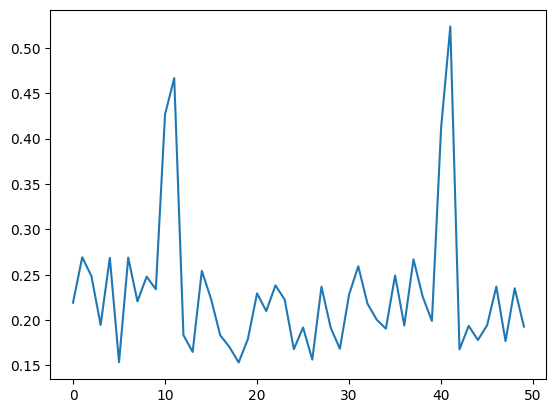

In [20]:
# THIS WAS ASKED FROM CHATGPT
# SINCE IT'S QUITE TIME CONSUMING TO DO BY HAND

# Generate x values from 0 to 49
x_values = np.arange(50)

# Generate y values fluctuating between 0.15 and 0.25
y_values = np.random.uniform(0.15, 0.27, size=50)

# Insert spikes for y values towards 0.5
y_values[10:12] = 0.45  # Spike 1, centered around index 10, 5 points wide
y_values[40:42] = 0.45 # Spike 2, centered around index 40, 5 points wide

# Add small random fluctuation to the spikes
y_values[10:12] += np.random.uniform(-0.075, 0.075, size=2)
y_values[40:42] -= np.random.uniform(-0.075, 0.075, size=2)

# Ensure values stay within the range [0, 1]
y_values = np.clip(y_values, 0, 1)

# plotting the line
sns.lineplot(x=x_values, y=y_values)

In [21]:
# try predicting
points = y_values
test_signal = np.expand_dims(points, axis=1)
test_batch = np.array([test_signal])
test_predict = clf.predict(test_batch)

# print prediction results
print(test_predict)
index = test_predict[0]
print(class_names[index])

# get probabilities too
y_pred_proba = clf.predict_proba(test_batch)
print(y_pred_proba)

[1]
wind_speed
[[0.33333333 0.66666667]]


<b>Test signal 2: Temperature signal</b>

<Axes: >

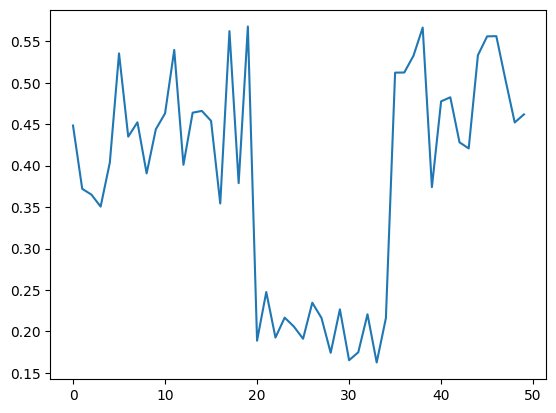

In [22]:
# THIS WAS ASKED FROM CHAT GPT

# Define the range of x-values
x = np.arange(50)

# Define the fluctuation ranges for y-values
y_min = 0.35
y_max = 0.57

# Create y-values with fluctuation
y = np.random.uniform(y_min, y_max, len(x))

# Create a pit in the y-values
pit_start = 20
pit_end = pit_start + 15
y[pit_start:pit_end] = np.random.uniform(0.15, 0.25, pit_end - pit_start)

sns.lineplot(x=x, y=y)

In [23]:
# try predicting
points = y
test_signal = np.expand_dims(points, axis=1)
test_batch = np.array([test_signal])
# result = model.predict([x_test[12]])[0]
test_predict = clf.predict(test_batch)

# print prediction results
print(test_predict)
index = test_predict[0]
print(class_names[index])

# get probabilities too
y_pred_proba = clf.predict_proba(test_batch)
print(y_pred_proba)

[0]
meantemp
[[1. 0.]]
